# Image Generation with Tiny-SD and OpenVINO™

In recent times, the AI community has witnessed a remarkable surge in the development of larger and more performant language models, such as Falcon 40B, LLaMa-2 70B, Falcon 40B, MPT 30B, and in the imaging domain with models like SD2.1 and SDXL. These advancements have undoubtedly pushed the boundaries of what AI can achieve, enabling highly versatile and state-of-the-art image generation and language understanding capabilities. However, the breakthrough of large models comes with substantial computational demands. To resolve this issue, recent research on efficient Stable Diffusion has prioritized reducing the number of sampling steps and utilizing network quantization.

Moving towards the goal of making image generative models faster, smaller, and cheaper, Tiny-SD was proposed by Segmind. Tiny SD is a compressed Stable Diffusion (SD) model that has been trained on Knowledge-Distillation (KD) techniques and the work has been largely based on this [paper](https://arxiv.org/pdf/2305.15798.pdf). The authors describe a Block-removal Knowledge-Distillation method where some of the UNet layers are removed and the student model weights are trained. Using the KD methods described in the paper, they were able to train two compressed models using the 🧨 diffusers library; Small and Tiny, that have 35% and 55% fewer parameters, respectively than the base model while achieving comparable image fidelity as the base model. More details about model can be found in [model card](https://huggingface.co/segmind/tiny-sd), [blog post](https://huggingface.co/blog/sd_distillation) and training [repository](https://github.com/segmind/distill-sd).

This notebook demonstrates how to convert and run the Tiny-SD model using OpenVINO.

The notebook contains the following steps:

1. Convert PyTorch models to OpenVINO Intermediate Representation using Optimum Intel.
2. Prepare Inference Pipeline.
3. Run Inference pipeline with OpenVINO.
4. Run Interactive demo for Tiny-SD model


<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/tiny-sd-image-generation/tiny-sd-image-generation.ipynb" />



#### Table of contents:

- [Prerequisites](#Prerequisites)
- [PyTorch Models pipeline](#PyTorch-Models-pipeline)
- [Convert the model](#Convert-the-model)
    - [Calibrate UNet for GPU inference](#Calibrate-UNet-for-GPU-inference)
- [Text-to-Image generation](#Text-to-Image-generation)
- [Image-to-Image generation](#Image-to-Image-generation)
- [Interactive Demo](#Interactive-Demo)


### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

## Prerequisites
[back to top ⬆️](#Table-of-contents:)

Install required dependencies

In [ ]:
%pip install -q --extra-index-url https://download.pytorch.org/whl/cpu "torch>=2.1" torchvision "opencv-python" "pillow" "diffusers>=0.18.0" "transformers>=4.45" "gradio>=4.19"
%pip install -q -U --pre --extra-index-url https://storage.openvinotoolkit.org/simple/wheels/nightly "openvino>=2024.5" "openvino-tokenizers>=2024.5" "openvino-genai>=2024.5"
%pip install -q "git+https://github.com/huggingface/optimum-intel.git"

In [ ]:
import requests


r = requests.get(
    url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
)
open("notebook_utils.py", "w").write(r.text)

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("tiny-sd-image-generation.ipynb")

## PyTorch Models pipeline
[back to top ⬆️](#Table-of-contents:)

![sd-pipeline](https://user-images.githubusercontent.com/29454499/260981188-c112dd0a-5752-4515-adca-8b09bea5d14a.png)

As you can see from the diagram, the only difference between Text-to-Image and text-guided Image-to-Image generation in approach is how initial latent state is generated. In case of Image-to-Image generation, you additionally have an image encoded by VAE encoder mixed with the noise produced by using latent seed, while in Text-to-Image you use only noise as initial latent state.

Next, the U-Net iteratively *denoises* the random latent image representations while being conditioned on the text embeddings. The output of the U-Net, being the noise residual, is used to compute a denoised latent image representation via a scheduler algorithm. Many different scheduler algorithms can be used for this computation, each having its pros and cons. For Stable Diffusion, it is recommended to use one of:

- [PNDM scheduler](https://github.com/huggingface/diffusers/blob/main/src/diffusers/schedulers/scheduling_pndm.py)
- [DDIM scheduler](https://github.com/huggingface/diffusers/blob/main/src/diffusers/schedulers/scheduling_ddim.py)
- [K-LMS scheduler](https://github.com/huggingface/diffusers/blob/main/src/diffusers/schedulers/scheduling_lms_discrete.py)(you will use it in your pipeline)

Theory on how the scheduler algorithm function works is out of scope for this notebook. Nonetheless, in short, you should remember that you compute the predicted denoised image representation from the previous noise representation and the predicted noise residual.
For more information, refer to the recommended [Elucidating the Design Space of Diffusion-Based Generative Models](https://arxiv.org/abs/2206.00364)

The *denoising* process is repeated given number of times (by default 50) to step-by-step retrieve better latent image representations.
When complete, the latent image representation is decoded by the decoder part of the variational auto encoder.

We've taken care to simplify the conversion process and hide all these details.

## Convert the model
[back to top ⬆️](#Table-of-contents:)

For convenience, we will use OpenVINO integration with HuggingFace Optimum. 🤗 [Optimum Intel](https://huggingface.co/docs/optimum/intel/index) is the interface between the 🤗 Transformers and Diffusers libraries and the different tools and libraries provided by Intel to accelerate end-to-end pipelines on Intel architectures.

Among other use cases, Optimum Intel provides a simple interface to optimize your Transformers and Diffusers models, convert them to the OpenVINO Intermediate Representation (IR) format and run inference using OpenVINO Runtime. `optimum-cli` provides command line interface for model conversion and optimization. 

General command format:

```bash
optimum-cli export openvino --model <model_id_or_path> --task <task> <output_dir>
```

where task is task to export the model for, if not specified, the task will be auto-inferred based on the model. You can find a mapping between tasks and model classes in Optimum TaskManager [documentation](https://huggingface.co/docs/optimum/exporters/task_manager). Additionally, you can specify weights compression using `--weight-format` argument with one of following options: `fp32`, `fp16`, `int8` and `int4`. Fro int8 and int4 [nncf](https://github.com/openvinotoolkit/nncf) will be used for  weight compression. More details about model export provided in [Optimum Intel documentation](https://huggingface.co/docs/optimum/intel/openvino/export#export-your-model).

In [4]:
from pathlib import Path

from PIL import Image

import openvino_genai as ov_genai


model_dir = Path("lcm-tiny-sd")

if not model_dir.exists():
    !optimum-cli export openvino -m katuni4ka/lcm-tiny-sd {model_dir} --weight-format fp16

### Calibrate UNet for GPU inference
[back to top ⬆️](#Table-of-contents:)


On a GPU device a model is executed in FP16 precision. For Tiny-SD UNet model there known to be accuracy issues caused by this. Therefore, a special calibration procedure is used to selectively mark some operations to be executed in full precision.

In [5]:
import pickle
import requests
import os


# Fetch `model_upcast_utils` which helps to restore accuracy when inferred on GPU
r = requests.get("https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/model_upcast_utils.py")
with open("model_upcast_utils.py", "w") as f:
    f.write(r.text)

# Fetch an example input for UNet model needed for upcasting calibration process
r = requests.get("https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/pkl/unet_calibration_example_input.pkl")
with open("unet_calibration_example_input.pkl", "wb") as f:
    f.write(r.content)

import openvino as ov
from model_upcast_utils import (
    is_model_partially_upcasted,
    partially_upcast_nodes_to_fp32,
)


core = ov.Core()
UNET_OV_PATH = model_dir / "unet/openvino_model.xml"
unet_model = core.read_model(UNET_OV_PATH)
if "GPU" in core.available_devices and not is_model_partially_upcasted(unet_model):
    with open("unet_calibration_example_input.pkl", "rb") as f:
        example_input = pickle.load(f)
    unet_model = partially_upcast_nodes_to_fp32(unet_model, example_input, upcast_ratio=0.7, operation_types=["Convolution"])

    ov.save_model(unet_model, UNET_OV_PATH.with_suffix("._tmp.xml"))
    del unet_model
    os.remove(UNET_OV_PATH)
    os.remove(str(UNET_OV_PATH).replace(".xml", ".bin"))
    UNET_OV_PATH.with_suffix("._tmp.xml").rename(UNET_OV_PATH)
    UNET_OV_PATH.with_suffix("._tmp.bin").rename(UNET_OV_PATH.with_suffix(".bin"))

## Text-to-Image generation
[back to top ⬆️](#Table-of-contents:)

Now, let's see model in action

### Select an inference device
[back to top ⬆️](#Table-of-contents:)

select device from dropdown list for running inference using OpenVINO

In [6]:
from notebook_utils import device_widget

device = device_widget()

device

Dropdown(description='Device:', index=1, options=('CPU', 'AUTO'), value='AUTO')

We will use [OpenVINO GenAI](https://github.com/openvinotoolkit/openvino.genai) that provides easy-to-use API for running image generation. Firstly we will create pipeline with `Text2ImagePipeline` and `Image2ImagePipeline`. You can see more details in [Image Python Generation Pipeline Example](https://github.com/openvinotoolkit/openvino.genai/tree/releases/2025/0/samples/python/image_generation)
Then we just run `generate` method and get the image tokens and then convert them into the image using `Image.fromarray` from PIL.

In [7]:
text2image_pipe = ov_genai.Text2ImagePipeline(model_dir, device.value)

In [8]:
text_prompt = "RAW studio photo of An intricate forest minitown landscape trapped in a bottle, atmospheric oliva lighting, on the table, intricate details, dark shot, soothing tones, muted colors "
seed = 99
num_steps = 30

In [9]:
print("Pipeline settings")
print(f"Input text: {text_prompt}")
print(f"Seed: {seed}")
print(f"Number of steps: {num_steps}")

Pipeline settings
Input text: RAW studio photo of An intricate forest minitown landscape trapped in a bottle, atmospheric oliva lighting, on the table, intricate details, dark shot, soothing tones, muted colors 
Seed: 99
Number of steps: 30


In [10]:
result = text2image_pipe.generate(text_prompt, num_inference_steps=num_steps, generator=ov_genai.TorchGenerator(seed))

Finally, let us save generation results.
The pipeline returns several results: `sample` contains final generated image, `iterations` contains list of intermediate results for each step.

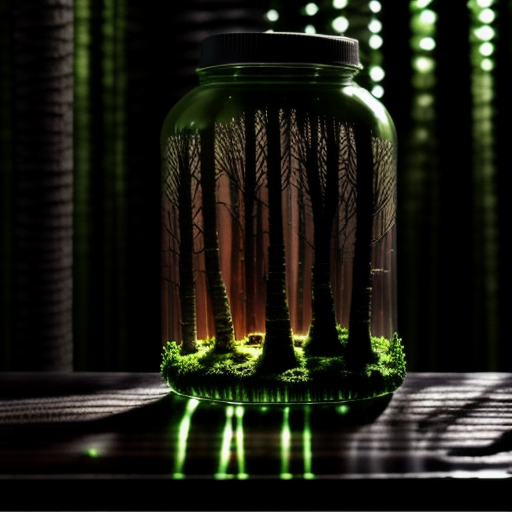

In [11]:
image = Image.fromarray(result.data[0])
image.save("result.png")
image

Nice. As you can see, the picture has quite a high definition 🔥.

## Image-to-Image generation
[back to top ⬆️](#Table-of-contents:)

One of the most amazing features of Stable Diffusion model is the ability to condition image generation from an existing image or sketch. Given a (potentially crude) image and the right text prompt, latent diffusion models can be used to “enhance” an image.

Image-to-Image generation, in additionally to the text prompt, requires providing the initial image. Optionally, you can also change `strength` parameter, which is a value between 0.0 and 1.0, that controls the amount of noise that is added to the input image. Values that approach 1.0 enable lots of variations but will also produce images that are not semantically consistent with the input. One of the interesting use cases for Image-to-Image generation is depainting - turning sketches or paintings into realistic photographs.

Additionally, to improve image generation quality, model supports negative prompting. Technically, positive prompt steers the diffusion toward the images associated with it, while negative prompt steers the diffusion away from it.In other words, negative prompt declares undesired concepts for generation image, e.g. if we want to have colorful and bright image, gray scale image will be result which we want to avoid, in this case gray scale can be treated as negative prompt. The positive and negative prompt are in equal footing. You can always use one with or without the other. More explanation of how it works can be found in this [article](https://stable-diffusion-art.com/how-negative-prompt-work/). 

In [12]:
image2image_pipe = ov_genai.Image2ImagePipeline(model_dir, device.value)

In [13]:
text_prompt_i2i = "professional photo portrait of woman, highly detailed, hyper realistic, cinematic effects, soft lighting"
negative_prompt_i2i = (
    "blurry, poor quality, low res, worst quality, cropped, ugly, poorly drawn face, without eyes, mutation, unreal, animate, poorly drawn eyes"
)
num_steps_i2i = 40
seed_i2i = 8098234
strength = 0.68

Also we convert the input image to `ov.Tensor` using `image_to_tensor` function. 

Pipeline settings
Input positive prompt: 
	professional photo portrait of woman, highly detailed, hyper realistic, cinematic effects, soft lighting
Input negative prompt: 
	blurry, poor quality, low res, worst quality, cropped, ugly, poorly drawn face, without eyes, mutation, unreal, animate, poorly drawn eyes
Seed: 8098234
Number of steps: 40
Strength: 0.68
Input image:


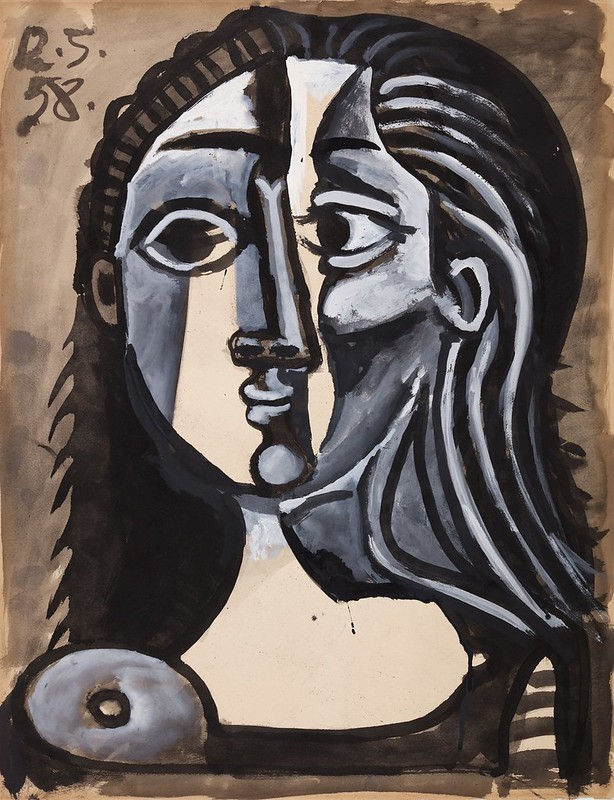

In [14]:
from diffusers.utils import load_image
import numpy as np

import openvino as ov


default_image_url = "https://user-images.githubusercontent.com/29454499/260418860-69cc443a-9ee6-493c-a393-3a97af080be7.jpg"
# read uploaded image
image = load_image(default_image_url)
print("Pipeline settings")
print(f"Input positive prompt: \n\t{text_prompt_i2i}")
print(f"Input negative prompt: \n\t{negative_prompt_i2i}")
print(f"Seed: {seed_i2i}")
print(f"Number of steps: {num_steps_i2i}")
print(f"Strength: {strength}")
print("Input image:")
display(image)


def image_to_tensor(image: Image) -> ov.Tensor:
    pic = image.convert("RGB")
    image_data = np.array(pic.getdata()).reshape(1, pic.size[1], pic.size[0], 3).astype(np.uint8)
    return ov.Tensor(image_data)


init_image = image_to_tensor(image)

In [15]:
processed_image = image2image_pipe.generate(
    text_prompt_i2i,
    init_image,
    negative_prompt=negative_prompt_i2i,
    num_inference_steps=num_steps_i2i,
    generator=ov_genai.TorchGenerator(seed_i2i),
    strength=strength,
)
final_image_i2i = Image.fromarray(processed_image.data[0])
final_image_i2i.save("result_i2i.png")

Input text:
	professional photo portrait of woman, highly detailed, hyper realistic, cinematic effects, soft lighting


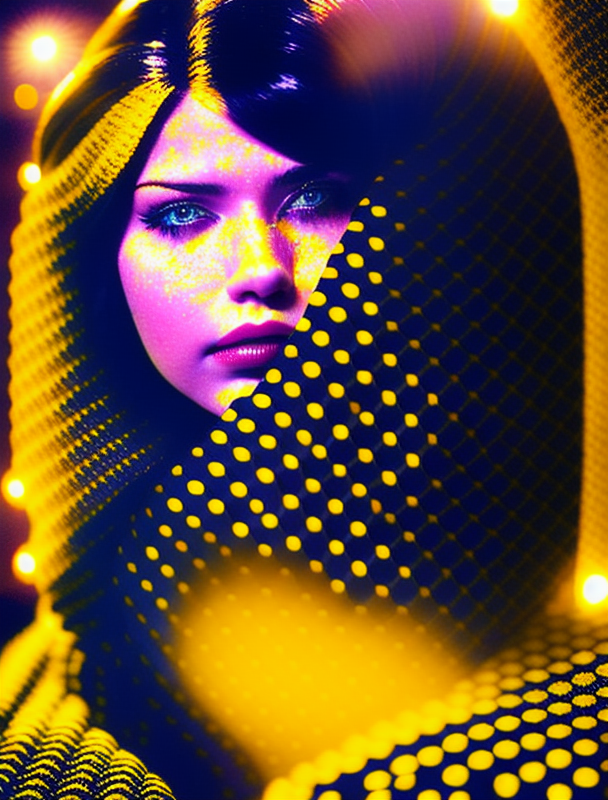

In [16]:
text_i2i = "\n\t".join(text_prompt_i2i.split("."))
print("Input text:")
print("\t" + text_i2i)
display(final_image_i2i)

### Interactive Demo
[back to top ⬆️](#Table-of-contents:)


In [ ]:
import gradio as gr


def generate_from_text(text, negative_text, seed, num_steps, _=gr.Progress(track_tqdm=True)):
    result = text2image_pipe.generate(text, negative_prompt=negative_text, num_inference_steps=num_steps, generator=ov_genai.TorchGenerator(seed))
    image = Image.fromarray(result.data[0])
    return image


def generate_from_image(img, text, negative_text, seed, num_steps, strength, _=gr.Progress(track_tqdm=True)):
    init_image = image_to_tensor(img)
    processed_image = image2image_pipe.generate(
        text,
        init_image,
        negative_prompt=negative_text,
        num_inference_steps=num_steps,
        generator=ov_genai.TorchGenerator(seed),
        strength=strength,
    )
    final_image = Image.fromarray(processed_image.data[0])
    return final_image

In [ ]:
if not Path("gradio_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/notebooks/tiny-sd-image-generation/gradio_helper.py")
    open("gradio_helper.py", "w").write(r.text)

from gradio_helper import make_demo

demo = make_demo(text_to_text_fn=generate_from_text, image_to_image_fn=generate_from_image)

try:
    demo.queue().launch(debug=True)
except Exception:
    demo.queue().launch(share=True, debug=True)
# If you are launching remotely, specify server_name and server_port
# EXAMPLE: `demo.launch(server_name='your server name', server_port='server port in int')`
# To learn more please refer to the Gradio docs: https://gradio.app/docs/

In [ ]:
# please uncomment and run this cell for stopping gradio interface
# demo.close()